# Cuaderno de clase
## Mecánica Celeste (2026-1) con Jorge I. Zuluaga
## Energía gravitacional

In [1]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt

Bienvenido a PyMCel v0.9.17 ¡al infinito y más allá!


## Sistema de dos cuerpos

In [2]:
G = 1 # En unidades canónicas

In [3]:
sistema = [
    dict(m=1,r=np.array([0,0,0]),v=np.array([0,0,0])),
    # dict(m=0.01,r=np.array([1,0,0]),v=np.array([0,1,0])) # No se escapa
    # dict(m=0.01,r=np.array([1,0,0]),v=np.array([0,3,0])) # Se escapa
    dict(m=0.01,r=np.array([1,0,0]),v=np.array([0,np.sqrt(2*G*1/1),0])) # Se escapa
]

Calculemos la energía total: $E = K + U$

In [4]:
K = 0.5 * sistema[0]['m'] * np.linalg.norm(sistema[0]['v'])**2 + \
    0.5 * sistema[1]['m'] * np.linalg.norm(sistema[1]['v'])**2

K

np.float64(0.010000000000000002)

In [5]:
U = - G * sistema[0]['m'] * sistema[1]['m'] \
    / np.linalg.norm(sistema[0]['r'] - sistema[1]['r'])

U

np.float64(-0.01)

In [6]:
E = K + U
E

np.float64(1.734723475976807e-18)

Ahora voy a probar con un experimento si efectivamente no escapa:

In [7]:
ts = np.linspace(0, 10, 100)
rs, vs, rps, vps, cuadraturas = pc.ncuerpos_solucion(sistema, ts)

Veamos las trayectorias:

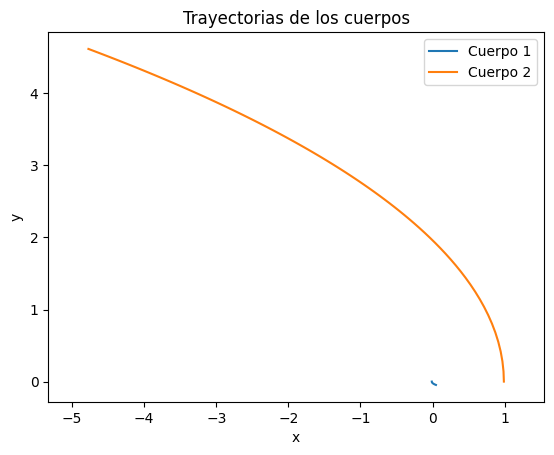

In [8]:
plt.plot(rps[0,:,0], rps[0,:,1], label='Cuerpo 1')
plt.plot(rps[1,:,0], rps[1,:,1], label='Cuerpo 2')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trayectorias de los cuerpos')
plt.legend()
plt.axis('equal')
plt.show()

## Hacer la simulación con Rebound

In [9]:
import rebound as rb

In [10]:
sim = rb.Simulation()

In [11]:
sim.G

1.0

In [12]:
sim.add(m=1)

In [13]:
sim.status()

---------------------------------
REBOUND version:     	4.6.0
REBOUND built on:    	Feb 23 2026 21:34:56
Number of particles: 	1
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x11c7c5050, m=1.0 x=0.0 y=0.0 z=0.0 vx=0.0 vy=0.0 vz=0.0>
---------------------------------
The following fields have non-default values:
N:
< 0
---
> 1
rand_seed:
< 873372
---
> 852616
particles:
> (128 bytes, values not printed)



In [14]:
sim.add(m=0.01, x=1, vy=1)

In [15]:
sim.status()

---------------------------------
REBOUND version:     	4.6.0
REBOUND built on:    	Feb 23 2026 21:34:56
Number of particles: 	2
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x11c7c53d0, m=1.0 x=0.0 y=0.0 z=0.0 vx=0.0 vy=0.0 vz=0.0>
<rebound.particle.Particle object at 0x11c7c54d0, m=0.01 x=1.0 y=0.0 z=0.0 vx=0.0 vy=1.0 vz=0.0>
---------------------------------
The following fields have non-default values:
N:
< 0
---
> 2
rand_seed:
< 885012
---
> 852616
particles:
> (256 bytes, values not printed)



Es conveniente usar una sola celda para crear el sistema:

In [16]:
sim = rb.Simulation()
sim.add(m=1)
sim.add(m=0.01, x=1, vy=1)

Integración:

In [17]:
ts = np.linspace(0, 10, 100)
rs = np.zeros((2, 100, 3))
vs = np.zeros((2, 100, 3))
rps = np.zeros((2, 100, 3))
vps = np.zeros((2, 100, 3))

for i,t in enumerate(ts):
    sim.integrate(t)
    rs[0,i] = sim.particles[0].xyz
    vs[0,i] = sim.particles[0].vxyz
    rs[1,i] = sim.particles[1].xyz
    vs[1,i] = sim.particles[1].vxyz
    sim.move_to_com()
    rps[0,i] = sim.particles[0].xyz
    vps[0,i] = sim.particles[0].vxyz
    rps[1,i] = sim.particles[1].xyz
    vps[1,i] = sim.particles[1].vxyz

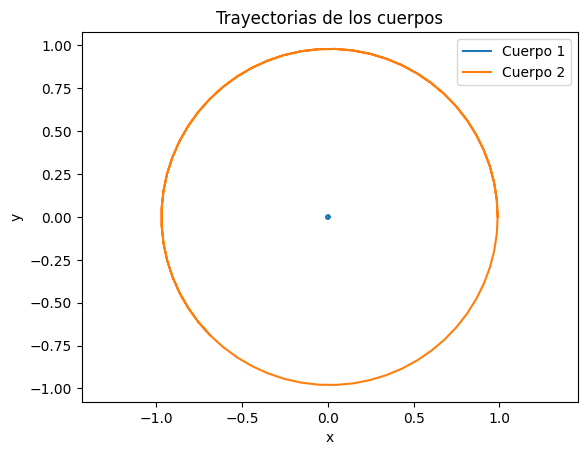

In [18]:
plt.plot(rps[0,:,0], rps[0,:,1], label='Cuerpo 1')
plt.plot(rps[1,:,0], rps[1,:,1], label='Cuerpo 2')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trayectorias de los cuerpos')
plt.legend()
plt.axis('equal')
plt.show()

## Simulaciones en el sistema solar con Rebound

Se puede usar Rebound no solo para hacer simulaciones de sistemas de prueba, sino también para simular sistemas con cuerpos del sistema solar.

In [19]:
sim_solar = rb.Simulation()
sim_solar.add('Sun',date='1975-06-19')
sim_solar.add('Earth',date='1975-06-19')
sim_solar.add('Apophis',date='1975-06-19')

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Earth'... 
Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
Searching NASA Horizons for 'Apophis'... 
Found: 99942 Apophis (2004 MN4) 


/Users/jzuluaga/dev/meccel-clase-1/.venv/lib/python3.13/site-packages/rebound/horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)
